# HyperTools 2.0 dev/testing notebook

Interactive companion to the `dev-2.0` modernization branch (see `notes/hypertools_2.0_roadmap.md`).

**Purpose:** exercise EVERY public function across the full use-case matrix, visually verify output, and compare backends. Each section corresponds to one public API function. Run top-to-bottom in Jupyter, Colab, or Kaggle — the three environments we must support.

**Use-case matrix** (applied to each function where relevant):

| dimension | cases |
|-|-|
| input type | single ndarray, list of ndarrays, DataFrame, list of DataFrames, nested lists (→ MultiIndex), text |
| dimensionality | 2D, 3D, high-D (reduced), 1D edge case |
| missing data | none, NaNs (PPCA fill) |
| styling | fmt strings, hue/group, legend, labels, title, multilevel-index color/thickness/opacity |
| coloring | categorical labels, continuous values, mixture proportions, user matrices, multicolored lines |
| models | reduce (PCA/IncrementalPCA/TSNE/UMAP), cluster (KMeans/HDBSCAN), mixtures (GaussianMixture/BayesianGaussianMixture/LDA/NMF), align (hyper/SRM) |
| animation | static, animate=True, spin, sliding window |
| backend | matplotlib (default), plotly (interactive) — 2.0 feature |

In [1]:
# Setup — when developing locally, install the branch in editable mode first:
#   pip install -e .
import sys, os, time
import numpy as np
import pandas as pd

t0 = time.time()
import hypertools as hyp
print(f'hypertools {hyp.__version__} imported in {time.time()-t0:.2f}s')  # 2.0 target: < 1s

ENV = 'colab' if 'google.colab' in sys.modules else ('kaggle' if os.path.exists('/kaggle') else 'local')
print('environment:', ENV)

hypertools 2.0.0.dev0 imported in 4.22s
environment: local


In [2]:
# Shared synthetic datasets (seeded for reproducibility)
rng = np.random.default_rng(42)
walk = np.cumsum(rng.standard_normal((200, 10)), axis=0)
walk2 = np.cumsum(np.random.default_rng(1).standard_normal((200, 10)), axis=0)
clusters = np.vstack([rng.standard_normal((60, 5)) + 6 * i for i in range(3)])
labels = [f'group{i}' for i in range(3) for _ in range(60)]
df = pd.DataFrame(walk, columns=[f'f{i}' for i in range(10)])
walk_missing = walk.copy(); walk_missing[rng.random(walk.shape) < 0.05] = np.nan

## 1. `hyp.plot` — core static cases

In [3]:
geo = hyp.plot(walk)                      # 3D trajectory, single array
hyp.plot([walk, walk2])                   # list -> auto color per element
hyp.plot(clusters, 'o')                   # scatter via fmt string
hyp.plot(walk, '--', ndims=2)             # 2D + dashed linestyle (regression: linestyle parsing)
hyp.plot(df);                             # DataFrame input

## 2. `hyp.plot` — models: reduce / cluster / align

In [4]:
hyp.plot(clusters, 'o', hue=labels, legend=True)
hyp.plot(clusters, 'o', cluster='KMeans', n_clusters=3)
hyp.plot(clusters, 'o', reduce='TSNE')
hyp.plot([walk, walk + 0.5], align='hyper')
hyp.plot(walk_missing);                   # PPCA missing-data interpolation

/Users/jmanning/hypertools/hypertools/tools/format_data.py:140: UserWarning: Missing data: Inexact solution computed with PPCA (see https://github.com/allentran/pca-magic for details)
  warnings.warn('Missing data: Inexact solution computed with PPCA (see https://github.com/allentran/pca-magic for details)')


## 3. `hyp.plot` — animation

Known-broken on master: numpy>=2 Jupyter animations (#265), Colab `animate=True` (#235), figures in loops (#264). These cells are the acceptance tests for the 2.0 fixes.

In [5]:
hyp.plot(walk, animate=True)              # sliding-window animation
hyp.plot(walk, animate='spin')            # camera spin
# regression #264: multiple figures in a loop
for seed in range(3):
    hyp.plot(np.cumsum(np.random.default_rng(seed).standard_normal((100, 5)), axis=0))

/Users/jmanning/hypertools/.venv/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
/Users/jmanning/hypertools/.venv/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


## 4. `hyp.plot` — 2.0 features (IMPLEMENTED on dev-2.0)

Backend switching, nested-list multilevel styling, mixture-model soft clustering, and matrix-valued hue. Each of these also has pytest coverage (`test_interactive.py`, `test_nested.py`, `test_colors.py`, `test_cluster.py`) and screenshot-harness cases.

In [6]:
# --- backend switching (approved policy: plotly only on Colab/Kaggle) ---
hyp.plot(walk, backend='matplotlib')      # explicit classic renderer
fig = hyp.plot(walk, backend='plotly')    # interactive plotly renderer
hyp.plot(walk, backend='auto')            # plotly on Colab/Kaggle, else matplotlib

# --- nested lists -> multilevel styling (color by outer group; deeper
# leaves render thinner + fainter) ---
hyp.plot([[walk, walk2], [np.cumsum(np.random.default_rng(7).standard_normal((200, 10)), axis=0)]])

# --- mixture models: soft clustering with blended colors ---
props = hyp.cluster(clusters, cluster='GaussianMixture', n_clusters=3)
print('mixture proportions:', props.shape, '(rows sum to 1)')
hyp.plot(clusters, 'o', cluster='GaussianMixture', n_clusters=3)

# --- robust coloring: matrix-valued hue (proportions, weights, any matrix) ---
hyp.plot(clusters, 'o', hue=props)
hyp.plot(walk, 'o', hue=np.arange(len(walk), dtype=float))  # continuous hue

# --- MULTICOLORED LINES: continuous/matrix hue + line fmt colors each
# trajectory continuously along its length (both backends) ---
hyp.plot(walk, hue=np.arange(len(walk), dtype=float))
hyp.plot(walk, hue=np.arange(len(walk), dtype=float), backend='plotly')

# --- apply_model: stack -> fit once -> unstack core ---
embedded = hyp.apply_model([walk, walk2], 'PCA', ndims=3)
print('shared embedding:', [e.shape for e in embedded])
pipe = hyp.apply_model(clusters, [{'model': 'PCA', 'params': {'n_components': 4}},
                                  {'model': 'TSNE', 'params': {'n_components': 2}}])
print('pipeline output:', pipe.shape)

# --- retired in 2.0 (raise clear errors now): plot(group=...), plot(model=...),
# reduce(model=/align=/normalize=), align(method=/align=True), cluster(ndims=) ---

mixture proportions: (180, 3) (rows sum to 1)


/Users/jmanning/hypertools/hypertools/plot/draw.py:49: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


shared embedding: [(200, 3), (200, 3)]


pipeline output: (180, 2)


## 5. `hyp.reduce`

In [7]:
print(hyp.reduce(walk, ndims=3).shape)
print(hyp.reduce([walk, walk2], ndims=2)[0].shape)
print(hyp.reduce(walk, reduce='IncrementalPCA', ndims=4).shape)

(200, 3)
(200, 2)
(200, 4)


## 6. `hyp.align`

In [8]:
aligned = hyp.align([walk, walk + 0.5])
print([a.shape for a in aligned])
aligned_srm = hyp.align([walk, walk + 0.5], align='SRM')
print([a.shape for a in aligned_srm])

[(200, 10), (200, 10)]
[(200, 10), (200, 10)]


## 7. `hyp.cluster`, `hyp.normalize`, `hyp.analyze`, `hyp.describe`

[0 1 2]
[-0.  0.  0.  0. -0.]
(200, 10)


/Users/jmanning/hypertools/hypertools/tools/describe.py:57: UserWarning: When input data is large, this computation can take a long time.
  warnings.warn('When input data is large, this computation can take a long time.')
/Users/jmanning/hypertools/hypertools/tools/describe.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


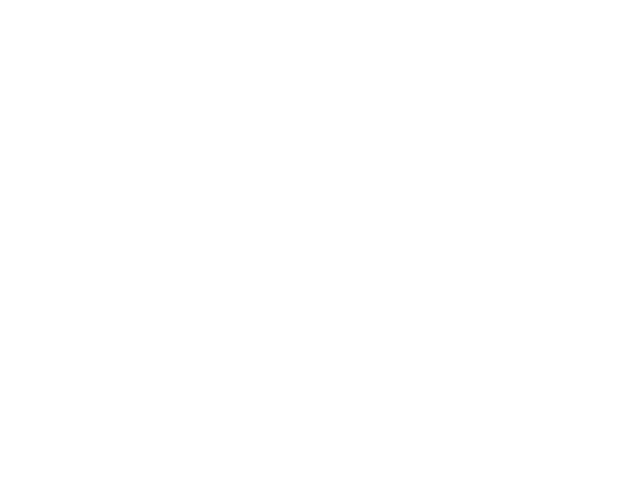

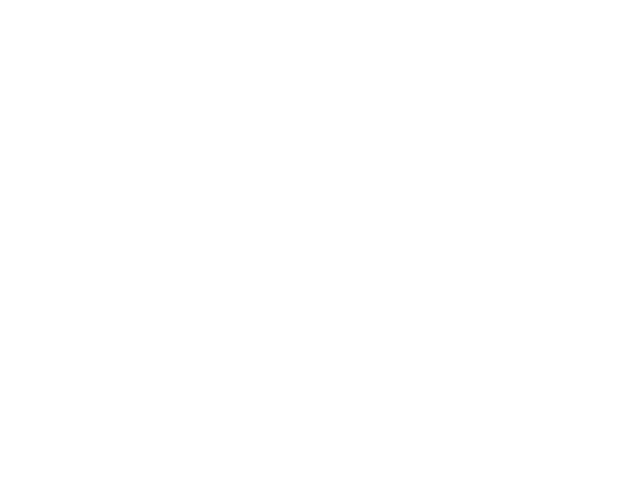

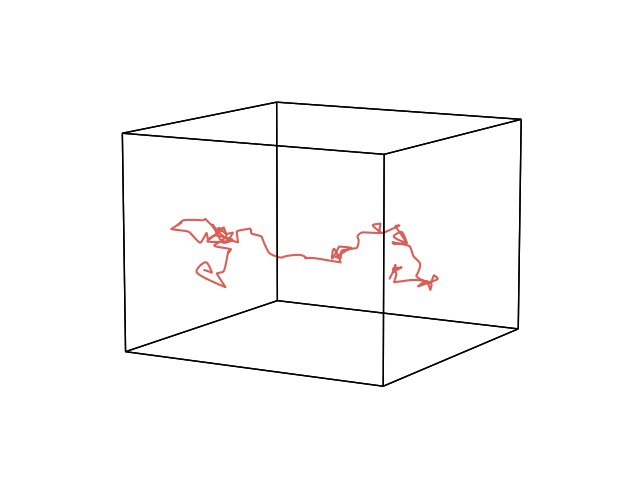

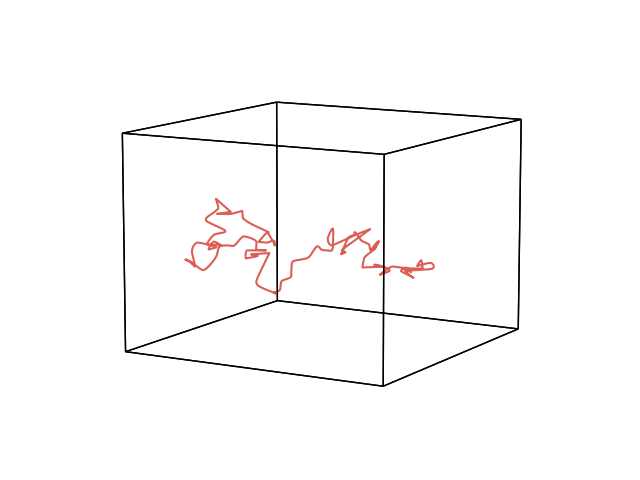

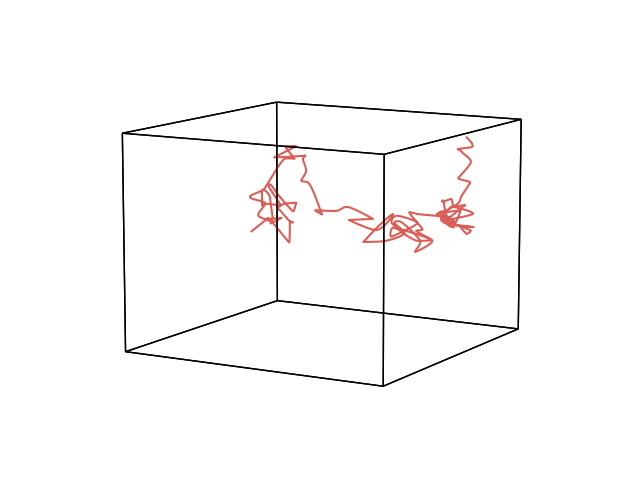

In [9]:
print(np.unique(hyp.cluster(clusters, n_clusters=3)))
print(hyp.normalize(walk).mean(axis=0).round(3)[:5])
print(hyp.analyze(walk, ndims=3, normalize='within').shape)
hyp.describe(walk);

## 8. `hyp.load` + text input (network required)

In [10]:
geo = hyp.load('weights_sample')
geo.plot()
hyp.plot(['the quick brown fox', 'jumped over the lazy dog',
          'machine learning is fun', 'high dimensional data'], 'o');

/Users/jmanning/hypertools/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator CountVectorizer from version 1.0.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/jmanning/hypertools/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LatentDirichletAllocation from version 1.0.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/jmanning/hypertools/.venv/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from vers

## 9. Screenshot capture (headless verification)

For the systematic screenshot matrix, run:
```bash
python scripts/generate_baseline_screenshots.py
```
and review PNGs under `tests/screenshots/`.